In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/cleaned_data.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Rows:", df.shape[0])
print("Ready for RFM!")

Rows: 805549
Ready for RFM!


In [2]:
# Reference date = 1 day after last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference date:", reference_date)

Reference date: 2011-12-10 12:50:00


In [3]:
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print(rfm.head(10))
print("\nShape:", rfm.shape)

   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   5633.32
2      12348.0       75          5   2019.40
3      12349.0       19          4   4428.69
4      12350.0      310          1    334.40
5      12351.0      375          1    300.93
6      12352.0       36         10   2849.84
7      12353.0      204          2    406.76
8      12354.0      232          1   1079.40
9      12355.0      214          2    947.61

Shape: (5878, 4)


In [4]:
# Recency: lower days = better = higher score
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4, 3, 2, 1])

# Frequency: higher = better = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])

# Monetary: higher = better = higher score
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=4, labels=[1, 2, 3, 4])

# Combined RFM score as string
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))

   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0      12346.0      326         12  77556.46       2       4       4       244
1      12347.0        2          8   5633.32       4       4       4       444
2      12348.0       75          5   2019.40       3       3       3       333
3      12349.0       19          4   4428.69       4       3       4       434
4      12350.0      310          1    334.40       2       1       1       211
5      12351.0      375          1    300.93       2       1       1       211
6      12352.0       36         10   2849.84       3       4       4       344
7      12353.0      204          2    406.76       2       2       2       222
8      12354.0      232          1   1079.40       2       1       3       213
9      12355.0      214          2    947.61       2       2       3       223


In [5]:
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r == 4 and f == 4 and m == 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r == 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'
    elif r == 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cannot Lose Them'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print(rfm['Segment'].value_counts())

Segment
Loyal Customers        1398
Needs Attention        1267
Lost                    734
Champions               661
At Risk                 654
Potential Loyalists     558
New Customers           336
Cannot Lose Them        270
Name: count, dtype: int64


In [6]:
segment_summary = rfm.groupby('Segment').agg(
    Total_Customers = ('Customer ID', 'count'),
    Avg_Recency     = ('Recency', 'mean'),
    Avg_Frequency   = ('Frequency', 'mean'),
    Avg_Monetary    = ('Monetary', 'mean')
).round(2).reset_index()

print(segment_summary.sort_values('Total_Customers', ascending=False).to_string())

               Segment  Total_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
4      Loyal Customers             1398        39.10           7.47       2851.95
5      Needs Attention             1267       356.15           2.35        672.39
3                 Lost              734       541.25           1.00        244.11
2            Champions              661        10.37          24.45      14567.99
0              At Risk              654       212.66           6.88       2702.24
7  Potential Loyalists              558        56.99           1.70        691.45
6        New Customers              336        13.71           1.90       1143.23
1     Cannot Lose Them              270       362.63           2.10       2069.05


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_25268\3053217154.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_counts.values, y=seg_counts.index, palette='RdYlGn')


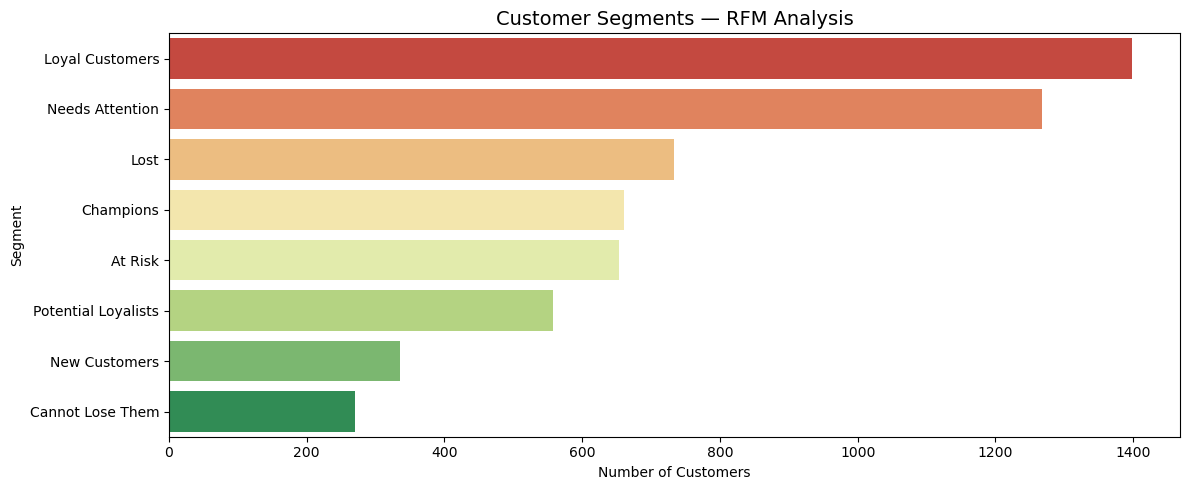

✅ Saved to outputs/chart_rfm_segments.png


In [7]:
seg_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(12, 5))
sns.barplot(x=seg_counts.values, y=seg_counts.index, palette='RdYlGn')
plt.title('Customer Segments — RFM Analysis', fontsize=14)
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.tight_layout()
plt.savefig('../outputs/chart_rfm_segments.png')
plt.show()
print("✅ Saved to outputs/chart_rfm_segments.png")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_25268\1751491614.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_revenue.values, y=seg_revenue.index, palette='Blues_r')


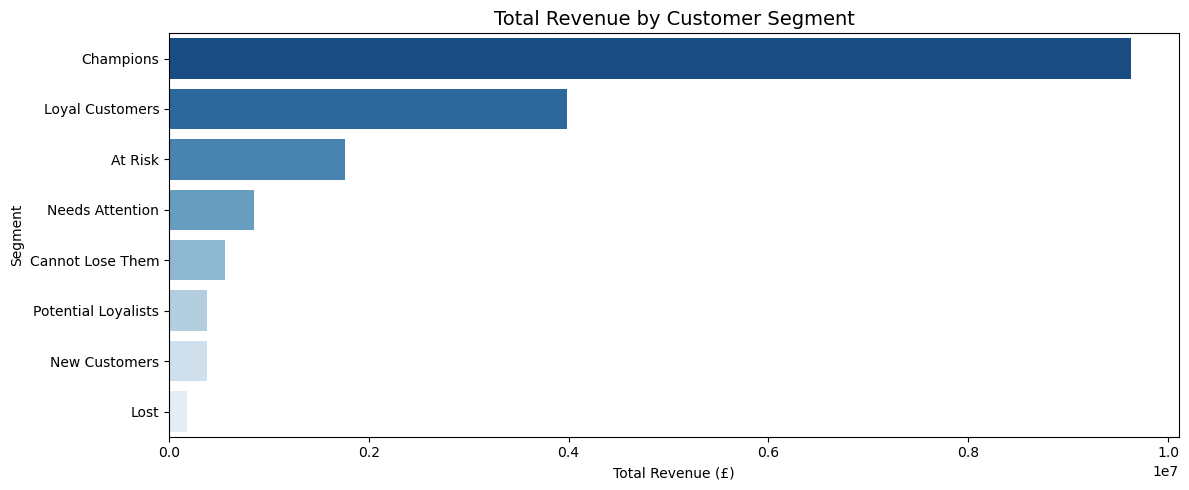

✅ Saved to outputs/chart_rfm_revenue.png


In [8]:
seg_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=seg_revenue.values, y=seg_revenue.index, palette='Blues_r')
plt.title('Total Revenue by Customer Segment', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Segment')
plt.tight_layout()
plt.savefig('../outputs/chart_rfm_revenue.png')
plt.show()
print("✅ Saved to outputs/chart_rfm_revenue.png")

In [9]:
total_revenue    = df['TotalPrice'].sum()
total_orders     = df['Invoice'].nunique()
total_customers  = df['Customer ID'].nunique()
aov              = total_revenue / total_orders
repeat_customers = rfm[rfm['Frequency'] > 1].shape[0]
repeat_rate      = (repeat_customers / total_customers) * 100
champions        = rfm[rfm['Segment'] == 'Champions'].shape[0]
lost_customers   = rfm[rfm['Segment'] == 'Lost'].shape[0]

print("============ KPI DASHBOARD ============")
print(f"Total Revenue:           £{total_revenue:,.2f}")
print(f"Total Orders:            {total_orders:,}")
print(f"Unique Customers:        {total_customers:,}")
print(f"Average Order Value:     £{aov:,.2f}")
print(f"Repeat Customer Rate:    {repeat_rate:.1f}%")
print(f"Champions:               {champions}")
print(f"Lost Customers:          {lost_customers}")

============ KPI DASHBOARD ============
Total Revenue:           £17,743,429.18
Total Orders:            36,969
Unique Customers:        5,878
Average Order Value:     £479.95
Repeat Customer Rate:    72.4%
Champions:               661
Lost Customers:          734


In [10]:
rfm.to_csv('../data/processed/rfm_segments.csv', index=False)

print("✅ Saved to data/processed/rfm_segments.csv")

✅ Saved to data/processed/rfm_segments.csv
